# 13 - Strict Reservation Under Historical Behavior

This playground studies one policy family: pooled FCFS at $Q=0$, then strict Class 1 reservation for $Q>0$. Both classes share a reservation window of $H=14$ days.

The notebook reports historical outcomes and two historical objectives. It does **not** calculate or recommend a preferred, best, or optimal value of $Q$.

## Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    from IPython.display import display
    HAS_WIDGETS = False


def find_repo_dir(start: Path) -> Path:
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "simulation" / "engine.py").exists() and (candidate / "analysis" / "metrics.py").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


REPO_DIR = find_repo_dir(Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from analysis.metrics import aggregate_result_row, class_result_rows
from simulation.engine import ClinicAppointmentSimulation
from simulation.model import PatientClassParams, SimulationConfig, ThresholdRule

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)

## Fixed Historical Design

Quick mode is the default. It runs exactly 50 simulations. Full mode runs exactly 6,750 simulations.

In [2]:
MODE = "quick"  # Change to "full" for the complete historical grid.
FORCE_RERUN = False
SAVE_CACHE = True

POOLED_POLICY = "Pooled FCFS"
STRICT_POLICY = "Strict C1 reservation"

SLOTS_PER_DAY = 32
HORIZON_DAYS = 14
BURN_IN_DAYS = 30
MEASURE_DAYS = 365
COOLDOWN_DAYS = 14
LAMBDA_1 = 50.0
LAMBDA_2 = 50.0
CANCEL_PROB = 0.10
NO_SHOW_RULE = {"threshold": 6, "low": 0.0, "high": 0.30}
BALK_LOW = 0.0
WEIGHTS = [(1.0, 1.0), (2.0, 1.0)]

FULL_THRESHOLD_PAIRS = [(9, 9), (5, 9), (9, 5), (12, 12), (5, 12)]
FULL_BALK_HIGHS = [0.3, 0.5, 0.7]
FULL_Q_VALUES = [0, 4, 8, 12, 16, 20, 24, 28, 32]
FULL_SEEDS = list(range(1, 51))

QUICK_THRESHOLD_PAIRS = [(9, 9), (5, 12)]
QUICK_BALK_HIGHS = [0.5]
QUICK_Q_VALUES = [0, 8, 16, 24, 32]
QUICK_SEEDS = list(range(1, 6))

if MODE == "quick":
    THRESHOLD_PAIRS = QUICK_THRESHOLD_PAIRS
    BALK_HIGHS = QUICK_BALK_HIGHS
    Q_VALUES = QUICK_Q_VALUES
    SEEDS = QUICK_SEEDS
elif MODE == "full":
    THRESHOLD_PAIRS = FULL_THRESHOLD_PAIRS
    BALK_HIGHS = FULL_BALK_HIGHS
    Q_VALUES = FULL_Q_VALUES
    SEEDS = FULL_SEEDS
else:
    raise ValueError("MODE must be 'quick' or 'full'.")

EXPECTED_RUNS = len(THRESHOLD_PAIRS) * len(BALK_HIGHS) * len(Q_VALUES) * len(SEEDS)
assert EXPECTED_RUNS == (50 if MODE == "quick" else 6750)

pd.Series({
    "mode": MODE,
    "simulation_runs": EXPECTED_RUNS,
    "threshold_pairs": THRESHOLD_PAIRS,
    "balk_high": BALK_HIGHS,
    "Q": Q_VALUES,
    "seeds": f"{SEEDS[0]}..{SEEDS[-1]}",
    "S": SLOTS_PER_DAY,
    "shared_H": HORIZON_DAYS,
    "lambda_1": LAMBDA_1,
    "lambda_2": LAMBDA_2,
    "cooldown": COOLDOWN_DAYS,
}, name="value").to_frame()

,value
mode,quick
simulation_runs,50
threshold_pairs,"[(9, 9), (5, 12)]"
balk_high,[0.5]
Q,"[0, 8, 16, 24, 32]"
seeds,1..5
S,32
shared_H,14
lambda_1,50.0
lambda_2,50.0


For class $i$, the balking probability is 0 through its threshold and `balk_high` after the threshold. The no-show probability is 0 through delay 6 and 0.30 after delay 6. Cancellation is 0.10.

The only objectives are

$$
U_{add}=w_1\frac{Y_1}{A_1}+w_2\frac{Y_2}{A_2},
$$

and

$$
U_{pool}=\frac{w_1Y_1+w_2Y_2}{w_1A_1+w_2A_2}.
$$

Here $A_i$ is arrivals and $Y_i$ is served patients. The weights are $(1,1)$ and $(2,1)$.

## Scenario Grid

In [3]:
scenario_rows = []
for threshold_1, threshold_2 in THRESHOLD_PAIRS:
    for balk_high in BALK_HIGHS:
        scenario_rows.append({
            "scenario_id": f"t{threshold_1}_{threshold_2}_b{balk_high:.1f}",
            "threshold_pair": f"({threshold_1}, {threshold_2})",
            "balk_threshold_1": threshold_1,
            "balk_threshold_2": threshold_2,
            "balk_high": float(balk_high),
        })

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)
print(f"Scenarios: {len(scenario_df)}; runs: {EXPECTED_RUNS:,}")

,scenario_id,threshold_pair,balk_threshold_1,balk_threshold_2,balk_high
0,t9_9_b0.5,"(9, 9)",9,9,0.5
1,t5_12_b0.5,"(5, 12)",5,12,0.5


Scenarios: 2; runs: 50


## Simulation And Accounting Helpers

In [4]:
def divide_or_nan(numerator: float, denominator: float) -> float:
    return numerator / denominator if denominator else np.nan


def divide_or_zero(numerator: float, denominator: float) -> float:
    return numerator / denominator if denominator else 0.0


def build_config(scenario: pd.Series, q: int, seed: int) -> SimulationConfig:
    classes = {
        1: PatientClassParams(
            class_id=1,
            lambda_per_day=LAMBDA_1,
            balk_prob=ThresholdRule(int(scenario["balk_threshold_1"]), BALK_LOW, float(scenario["balk_high"])),
            cancel_prob=CANCEL_PROB,
            no_show_prob=ThresholdRule(**NO_SHOW_RULE),
            horizon_days=HORIZON_DAYS,
        ),
        2: PatientClassParams(
            class_id=2,
            lambda_per_day=LAMBDA_2,
            balk_prob=ThresholdRule(int(scenario["balk_threshold_2"]), BALK_LOW, float(scenario["balk_high"])),
            cancel_prob=CANCEL_PROB,
            no_show_prob=ThresholdRule(**NO_SHOW_RULE),
            horizon_days=HORIZON_DAYS,
        ),
    }
    return SimulationConfig(
        slots_per_day=SLOTS_PER_DAY,
        horizon_days=HORIZON_DAYS,
        burn_in_days=BURN_IN_DAYS,
        measure_days=MEASURE_DAYS,
        cooldown_days=COOLDOWN_DAYS,
        classes=classes,
        seed=seed,
        reserved_class_id=1 if q > 0 else None,
        reserved_slots_per_day=q,
    )


def summarize_result(result, fixed: dict) -> tuple[dict, list[dict]]:
    aggregate = aggregate_result_row(result, fixed)
    raw_class_rows = class_result_rows(result, fixed)
    by_class = {row["class_id"]: row for row in raw_class_rows}

    run_row = {
        **aggregate,
        "served_rate": divide_or_zero(aggregate["total_served"], aggregate["total_arrivals"]),
        "no_offer_rate": divide_or_zero(aggregate["total_no_offer"], aggregate["total_arrivals"]),
        "unresolved_rate": divide_or_zero(aggregate["total_unresolved_booked"], aggregate["total_arrivals"]),
        "class_1_arrivals": by_class[1]["arrivals"],
        "class_2_arrivals": by_class[2]["arrivals"],
        "class_1_served": by_class[1]["served"],
        "class_2_served": by_class[2]["served"],
        "class_1_served_rate": by_class[1]["percent_serviced"],
        "class_2_served_rate": by_class[2]["percent_serviced"],
    }

    enriched = []
    for row in raw_class_rows:
        unresolved = row["booked"] - row["canceled"] - row["no_show"] - row["served"]
        enriched.append({
            **row,
            "served_rate": divide_or_zero(row["served"], row["arrivals"]),
            "no_offer_rate": divide_or_zero(row["no_offer"], row["arrivals"]),
            "offered_rate": divide_or_zero(row["offered"], row["arrivals"]),
            "unresolved_booked": unresolved,
            "unresolved_rate": divide_or_zero(unresolved, row["arrivals"]),
            # A wait is undefined when nobody in the class received an offer.
            "mean_offered_booking_delay": divide_or_nan(row["total_offered_booking_delay"], row["offered"]),
        })
    return run_row, enriched


def accounting_table(run_df: pd.DataFrame, class_df: pd.DataFrame) -> pd.DataFrame:
    run_residual = run_df["total_arrivals"] - (
        run_df["total_served"] + run_df["total_balked"] + run_df["total_no_offer"]
        + run_df["total_canceled"] + run_df["total_no_show"] + run_df["total_unresolved_booked"]
    )
    class_residual = class_df["arrivals"] - (
        class_df["served"] + class_df["balked"] + class_df["no_offer"]
        + class_df["canceled"] + class_df["no_show"] + class_df["unresolved_booked"]
    )
    return pd.DataFrame({
        "check": ["run outcome partition", "class outcome partition", "offered = booked + balked", "wait is NaN when no offers"],
        "max_absolute_error": [
            run_residual.abs().max(),
            class_residual.abs().max(),
            (class_df["offered"] - class_df["booked"] - class_df["balked"]).abs().max(),
            float((class_df.loc[class_df["offered"] == 0, "mean_offered_booking_delay"].notna()).sum()),
        ],
    })

In [5]:
def run_grid() -> tuple[pd.DataFrame, pd.DataFrame]:
    run_rows = []
    class_rows = []
    tasks = [
        (scenario, seed, q)
        for _, scenario in scenario_df.iterrows()
        for seed in SEEDS
        for q in Q_VALUES
    ]
    for scenario, seed, q in tqdm(tasks, total=EXPECTED_RUNS, desc=f"{MODE} simulations"):
        policy = POOLED_POLICY if q == 0 else STRICT_POLICY
        fixed = {
            **scenario.to_dict(),
            "seed": int(seed),
            "Q": int(q),
            "policy": policy,
        }
        result = ClinicAppointmentSimulation(build_config(scenario, int(q), int(seed))).run()
        run_row, result_class_rows = summarize_result(result, fixed)
        run_rows.append(run_row)
        class_rows.extend(result_class_rows)
    return pd.DataFrame(run_rows), pd.DataFrame(class_rows)


def make_objective_tables(run_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for _, row in run_df.iterrows():
        a1, a2 = row["class_1_arrivals"], row["class_2_arrivals"]
        y1, y2 = row["class_1_served"], row["class_2_served"]
        for w1, w2 in WEIGHTS:
            common = {**row.to_dict(), "w1": w1, "w2": w2, "weight_label": f"({w1:g}, {w2:g})"}
            rows.append({**common, "objective": "U_add", "objective_value": w1 * divide_or_zero(y1, a1) + w2 * divide_or_zero(y2, a2)})
            rows.append({**common, "objective": "U_pool", "objective_value": divide_or_zero(w1 * y1 + w2 * y2, w1 * a1 + w2 * a2)})

    objective_df = pd.DataFrame(rows)
    pair_keys = ["scenario_id", "threshold_pair", "balk_threshold_1", "balk_threshold_2", "balk_high", "seed", "w1", "w2", "weight_label", "objective"]
    baseline = objective_df.loc[objective_df["Q"] == 0, pair_keys + ["objective_value"]].rename(columns={"objective_value": "q0_objective_value"})
    paired_df = objective_df.loc[objective_df["Q"] > 0].merge(baseline, on=pair_keys, how="left", validate="many_to_one")
    paired_df["objective_delta"] = paired_df["objective_value"] - paired_df["q0_objective_value"]
    if paired_df["q0_objective_value"].isna().any():
        raise AssertionError("At least one strict run is missing its scenario/seed Q=0 pair.")
    return objective_df, paired_df

## Fingerprinted Cache

The cache contains run, class, objective, and paired tables. The key combines the experiment configuration with hashes of the simulation and metric source files.

In [6]:
def stable_json(value: dict) -> str:
    return json.dumps(value, sort_keys=True, separators=(",", ":"), default=str)


def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


SOURCE_FILES = [
    REPO_DIR / "simulation" / "engine.py",
    REPO_DIR / "simulation" / "model.py",
    REPO_DIR / "analysis" / "metrics.py",
]
SOURCE_FINGERPRINT = sha256_text("".join(path.read_text(encoding="utf-8") for path in SOURCE_FILES))
CONFIG = {
    "cache_schema": "strict_reservation_behavior_context_v1",
    "mode": MODE,
    "slots_per_day": SLOTS_PER_DAY,
    "horizon_days": HORIZON_DAYS,
    "burn_in_days": BURN_IN_DAYS,
    "measure_days": MEASURE_DAYS,
    "cooldown_days": COOLDOWN_DAYS,
    "lambda_1": LAMBDA_1,
    "lambda_2": LAMBDA_2,
    "cancel_prob": CANCEL_PROB,
    "no_show_rule": NO_SHOW_RULE,
    "balk_low": BALK_LOW,
    "threshold_pairs": THRESHOLD_PAIRS,
    "balk_highs": BALK_HIGHS,
    "q_values": Q_VALUES,
    "seeds": SEEDS,
    "weights": WEIGHTS,
}
CONFIG_FINGERPRINT = sha256_text(stable_json(CONFIG))
CACHE_KEY = sha256_text(SOURCE_FINGERPRINT + CONFIG_FINGERPRINT)[:16]
CACHE_ROOT = REPO_DIR / "notebooks" / "temp" / "strict_reservation_behavior_context"
CACHE_DIR = CACHE_ROOT / CACHE_KEY
CACHE_PATHS = {
    "run": CACHE_DIR / "run.pkl",
    "class": CACHE_DIR / "class.pkl",
    "objective": CACHE_DIR / "objective.pkl",
    "paired": CACHE_DIR / "paired.pkl",
    "manifest": CACHE_DIR / "manifest.json",
}
MANIFEST = {
    "source_fingerprint": SOURCE_FINGERPRINT,
    "config_fingerprint": CONFIG_FINGERPRINT,
    "cache_key": CACHE_KEY,
    "config": CONFIG,
}

cache_ready = all(path.exists() for path in CACHE_PATHS.values())
if cache_ready and not FORCE_RERUN:
    cached_manifest = json.loads(CACHE_PATHS["manifest"].read_text(encoding="utf-8"))
    cache_ready = cached_manifest == MANIFEST

if cache_ready and not FORCE_RERUN:
    run_df = pd.read_pickle(CACHE_PATHS["run"])
    class_df = pd.read_pickle(CACHE_PATHS["class"])
    objective_df = pd.read_pickle(CACHE_PATHS["objective"])
    paired_df = pd.read_pickle(CACHE_PATHS["paired"])
    print(f"Loaded cache: {CACHE_DIR}")
else:
    run_df, class_df = run_grid()
    objective_df, paired_df = make_objective_tables(run_df)
    if SAVE_CACHE:
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        run_df.to_pickle(CACHE_PATHS["run"])
        class_df.to_pickle(CACHE_PATHS["class"])
        objective_df.to_pickle(CACHE_PATHS["objective"])
        paired_df.to_pickle(CACHE_PATHS["paired"])
        CACHE_PATHS["manifest"].write_text(json.dumps(MANIFEST, indent=2, sort_keys=True), encoding="utf-8")
        print(f"Saved cache: {CACHE_DIR}")

assert len(run_df) == EXPECTED_RUNS
assert len(class_df) == 2 * EXPECTED_RUNS
assert set(run_df.loc[run_df["Q"] == 0, "policy"]) == {POOLED_POLICY}
assert set(run_df.loc[run_df["Q"] > 0, "policy"]) == {STRICT_POLICY}

print(f"Source fingerprint: {SOURCE_FINGERPRINT[:16]}")
print(f"Config fingerprint: {CONFIG_FINGERPRINT[:16]}")
print(f"Rows: run={len(run_df):,}, class={len(class_df):,}, objective={len(objective_df):,}, paired={len(paired_df):,}")

quick simulations:   0%|          | 0/50 [00:00<?, ?it/s]

Saved cache: /Users/alexandresepulvedadedietrich/CUIMC-Appointment-Simulation/notebooks/temp/strict_reservation_behavior_context/d0a8bd3f601fd35a
Source fingerprint: d6dfabfd58750f8b
Config fingerprint: 97ad946133a0d2d9
Rows: run=50, class=100, objective=200, paired=160


## Accounting Checks

In [7]:
checks_df = accounting_table(run_df, class_df)
display(checks_df)
assert (checks_df["max_absolute_error"] == 0).all()
assert class_df.loc[class_df["offered"] == 0, "mean_offered_booking_delay"].isna().all()
print(f"Maximum unresolved booked count in one run: {int(run_df['total_unresolved_booked'].max())}")

,check,max_absolute_error
0,run outcome partition,0.0
1,class outcome partition,0.0
2,offered = booked + balked,0.0
3,wait is NaN when no offers,0.0


Maximum unresolved booked count in one run: 0


## Paired Summary Tables

All deltas below subtract the pooled FCFS result for the same scenario and seed.

In [8]:
objective_summary = (
    paired_df.groupby(["threshold_pair", "balk_high", "Q", "weight_label", "objective"])["objective_delta"]
    .agg(mean="mean", std="std", count="count", min="min", max="max")
    .reset_index()
)
objective_summary["sem"] = objective_summary["std"].fillna(0) / np.sqrt(objective_summary["count"])
objective_summary["ci_low"] = objective_summary["mean"] - 1.96 * objective_summary["sem"]
objective_summary["ci_high"] = objective_summary["mean"] + 1.96 * objective_summary["sem"]

baseline_class = class_df.loc[class_df["Q"] == 0, ["scenario_id", "seed", "class_id", "served_rate", "no_offer_rate", "offered", "mean_offered_booking_delay"]].rename(columns={
    "served_rate": "q0_served_rate",
    "no_offer_rate": "q0_no_offer_rate",
    "offered": "q0_offered",
    "mean_offered_booking_delay": "q0_mean_offered_booking_delay",
})
paired_class_df = class_df.loc[class_df["Q"] > 0].merge(baseline_class, on=["scenario_id", "seed", "class_id"], how="left", validate="many_to_one")
for metric in ["served_rate", "no_offer_rate", "offered", "mean_offered_booking_delay"]:
    paired_class_df[f"delta_{metric}"] = paired_class_df[metric] - paired_class_df[f"q0_{metric}"]

display(objective_summary.head(12))
display(paired_class_df.head(8))

,threshold_pair,balk_high,Q,weight_label,objective,mean,std,count,min,max,sem,ci_low,ci_high
0,"(5, 12)",0.5,8,"(1, 1)",U_add,0.001846,0.003979,5,-0.002762,0.007632,0.001780,-0.001642,0.005334
1,"(5, 12)",0.5,8,"(1, 1)",U_pool,0.000868,0.001959,5,-0.001362,0.003714,0.000876,-0.000849,0.002585
2,"(5, 12)",0.5,8,"(2, 1)",U_add,0.009612,0.004838,5,0.002519,0.015102,0.002164,0.005371,0.013853
3,"(5, 12)",0.5,8,"(2, 1)",U_pool,0.003155,0.001575,5,0.000857,0.004943,0.000704,0.001775,0.004536
4,"(5, 12)",0.5,16,"(1, 1)",U_add,0.000819,0.005290,5,-0.004858,0.008066,0.002366,-0.003817,0.005456
5,"(5, 12)",0.5,16,"(1, 1)",U_pool,0.000237,0.002777,5,-0.002715,0.004177,0.001242,-0.002198,0.002671
6,"(5, 12)",0.5,16,"(2, 1)",U_add,0.061630,0.006943,5,0.053659,0.071789,0.003105,0.055544,0.067715
7,"(5, 12)",0.5,16,"(2, 1)",U_pool,0.020389,0.002425,5,0.017761,0.024058,0.001084,0.018264,0.022514
8,"(5, 12)",0.5,24,"(1, 1)",U_add,0.075460,0.004956,5,0.070270,0.082588,0.002217,0.071116,0.079805
9,"(5, 12)",0.5,24,"(1, 1)",U_pool,0.037842,0.002582,5,0.034992,0.041437,0.001155,0.035579,0.040105


,scenario_id,threshold_pair,balk_threshold_1,balk_threshold_2,balk_high,seed,Q,policy,class_id,arrivals,booked,balked,offered,no_offer,canceled,no_show,served,mean_accepted_booking_delay,mean_offered_booking_delay,percent_serviced,slot_utilization,booked_slot_utilization,balking_rate,total_booking_delay,total_offered_booking_delay,served_rate,no_offer_rate,offered_rate,unresolved_booked,unresolved_rate,q0_served_rate,q0_no_offer_rate,q0_offered,q0_mean_offered_booking_delay,delta_served_rate,delta_no_offer_rate,delta_offered,delta_mean_offered_booking_delay
0,t9_9_b0.5,"(9, 9)",9,9,0.5,1,8,Strict C1 reservation,1,18030,11539,6491,18030,0,5707,917,4915,8.143947,9.120799,0.272601,0.420805,0.499315,0.360011,93973.0,164448.0,0.272601,0.000000,1.000000,0,0.0,0.270031,0.0,18446,9.323105,0.002570,0.000000,-416,-0.202307
1,t9_9_b0.5,"(9, 9)",9,9,0.5,1,8,Strict C1 reservation,2,18136,11560,6576,18136,0,5733,953,4874,8.311073,9.232300,0.268747,0.417295,0.498887,0.362594,96076.0,167437.0,0.268747,0.000000,1.000000,0,0.0,0.264751,0.0,18270,9.354461,0.003996,0.000000,-134,-0.122160
2,t9_9_b0.5,"(9, 9)",9,9,0.5,1,16,Strict C1 reservation,1,18124,12186,5938,18124,0,5740,965,5481,7.711800,8.627731,0.302417,0.469264,0.551884,0.327632,93976.0,156369.0,0.302417,0.000000,1.000000,0,0.0,0.270031,0.0,18446,9.323105,0.032385,0.000000,-322,-0.695374
3,t9_9_b0.5,"(9, 9)",9,9,0.5,1,16,Strict C1 reservation,2,18353,11221,6970,18191,162,5994,903,4324,9.145263,10.110879,0.235602,0.370205,0.447517,0.383157,102619.0,183927.0,0.235602,0.008827,0.991173,0,0.0,0.264751,0.0,18270,9.354461,-0.029149,0.008827,-79,0.756418
4,t9_9_b0.5,"(9, 9)",9,9,0.5,1,24,Strict C1 reservation,1,18364,16011,2353,18364,0,7150,1418,7443,7.148960,7.514267,0.405304,0.637243,0.758647,0.128131,114462.0,137992.0,0.405304,0.000000,1.000000,0,0.0,0.270031,0.0,18446,9.323105,0.135272,0.000000,-82,-1.808838
5,t9_9_b0.5,"(9, 9)",9,9,0.5,1,24,Strict C1 reservation,2,18433,6289,3849,10138,8295,3462,437,2390,9.574813,10.697869,0.129659,0.204623,0.242038,0.379661,60216.0,108455.0,0.129659,0.450008,0.549992,0,0.0,0.264751,0.0,18270,9.354461,-0.135092,0.450008,-8132,1.343409
6,t9_9_b0.5,"(9, 9)",9,9,0.5,1,32,Strict C1 reservation,1,18034,18034,0,18034,0,6355,858,10821,5.375735,5.375735,0.600033,0.926455,0.999914,0.000000,96946.0,96946.0,0.600033,0.000000,1.000000,0,0.0,0.270031,0.0,18446,9.323105,0.330002,0.000000,-412,-3.947371
7,t9_9_b0.5,"(9, 9)",9,9,0.5,1,32,Strict C1 reservation,2,18107,0,0,0,18107,0,0,0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.000000,0.000000,0,0.0,0.264751,0.0,18270,9.354461,-0.264751,1.000000,-18270,NaN


## Objective Deltas

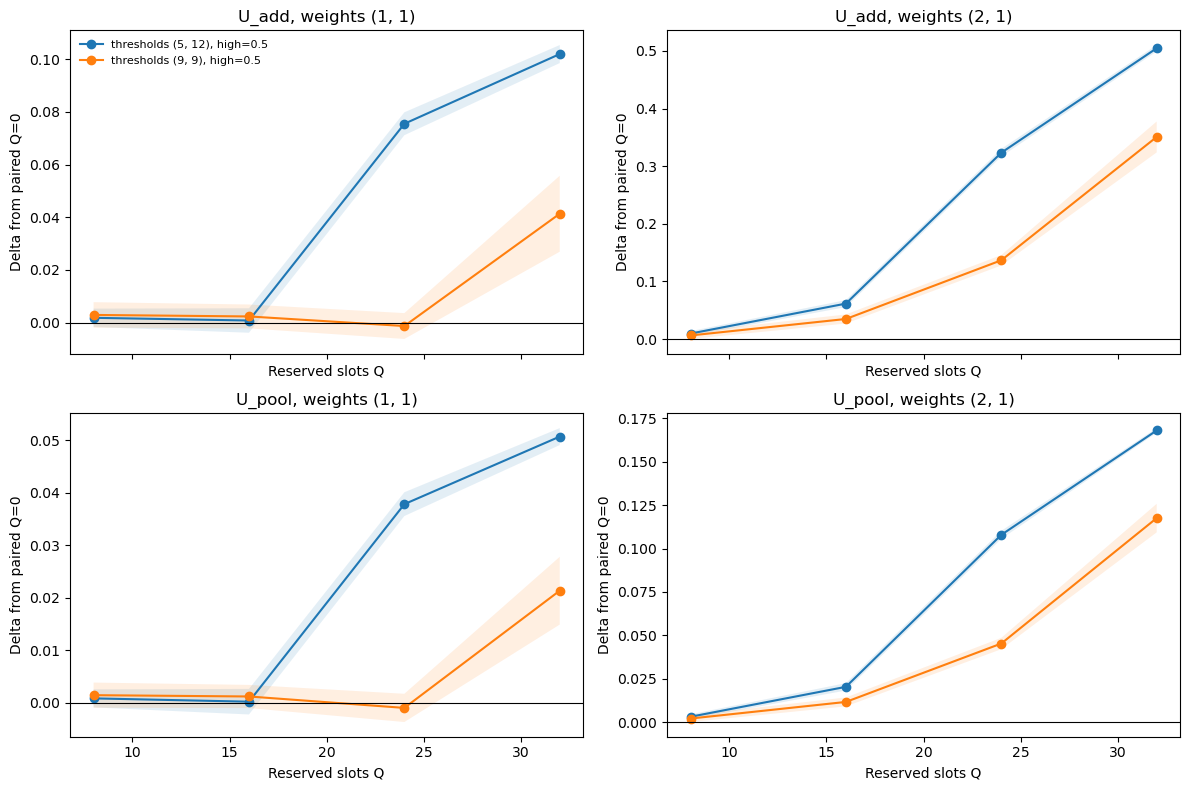

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, ((objective, weight_label), group) in zip(axes.flat, objective_summary.groupby(["objective", "weight_label"], sort=True)):
    for (threshold_pair, balk_high), line in group.groupby(["threshold_pair", "balk_high"]):
        line = line.sort_values("Q")
        label = f"thresholds {threshold_pair}, high={balk_high:g}"
        ax.plot(line["Q"], line["mean"], marker="o", label=label)
        ax.fill_between(line["Q"], line["ci_low"], line["ci_high"], alpha=0.12)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{objective}, weights {weight_label}")
    ax.set_xlabel("Reserved slots Q")
    ax.set_ylabel("Delta from paired Q=0")
axes[0, 0].legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

## Class Service, No Offer, And Offered Delay

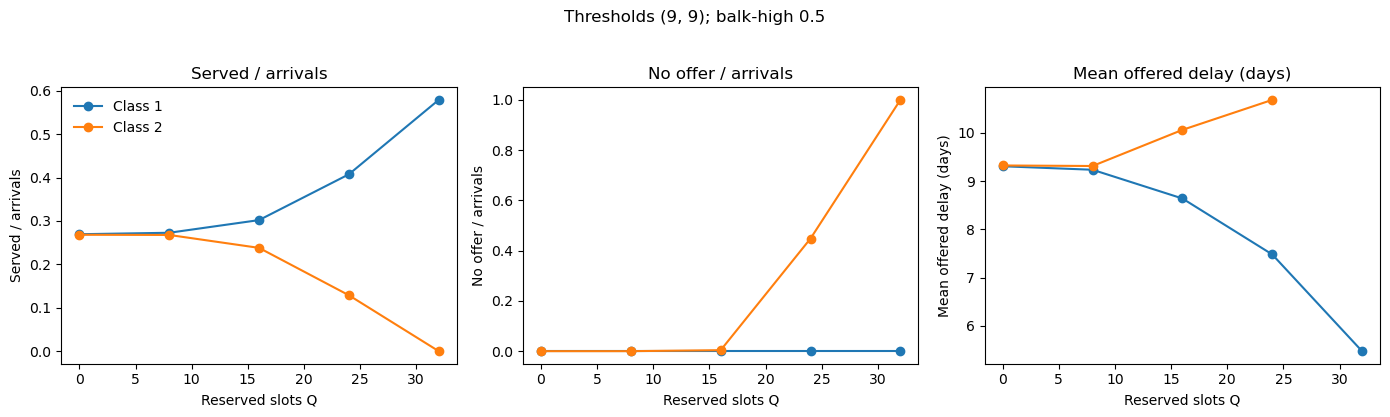

In [10]:
def plot_class_context(threshold_pair: str, balk_high: float) -> None:
    selected = class_df[(class_df["threshold_pair"] == threshold_pair) & np.isclose(class_df["balk_high"], balk_high)]
    summary = selected.groupby(["Q", "class_id"])[["served_rate", "no_offer_rate", "mean_offered_booking_delay"]].mean().reset_index()
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = {
        "served_rate": "Served / arrivals",
        "no_offer_rate": "No offer / arrivals",
        "mean_offered_booking_delay": "Mean offered delay (days)",
    }
    for ax, metric in zip(axes, labels):
        for class_id, line in summary.groupby("class_id"):
            ax.plot(line["Q"], line[metric], marker="o", label=f"Class {class_id}")
        ax.set_title(labels[metric])
        ax.set_xlabel("Reserved slots Q")
        ax.set_ylabel(labels[metric])
    axes[0].legend(frameon=False)
    fig.suptitle(f"Thresholds {threshold_pair}; balk-high {balk_high:g}", y=1.03)
    fig.tight_layout()
    plt.show()


# Plain-cell fallback: edit these two values and rerun this cell.
PLOT_THRESHOLD_PAIR = scenario_df.iloc[0]["threshold_pair"]
PLOT_BALK_HIGH = float(scenario_df.iloc[0]["balk_high"])
plot_class_context(PLOT_THRESHOLD_PAIR, PLOT_BALK_HIGH)

## Seed Variation

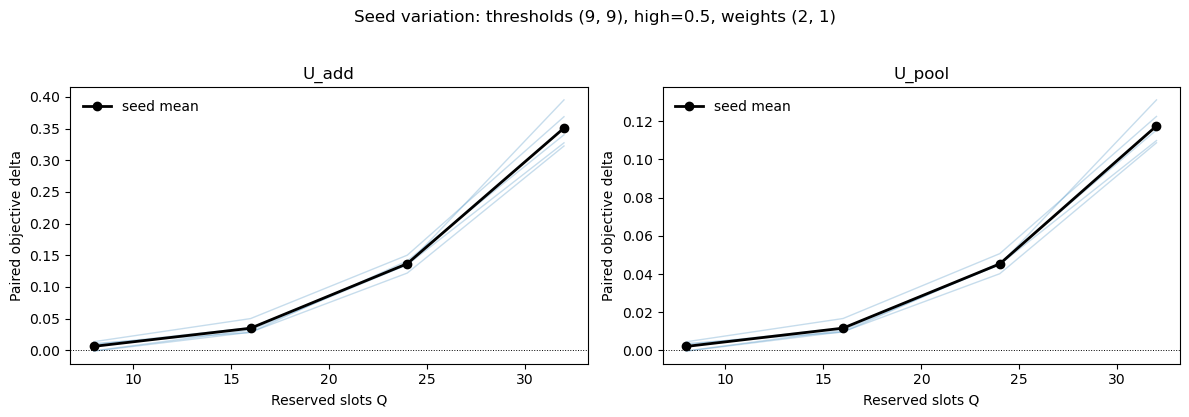

In [11]:
seed_view = paired_df[
    (paired_df["threshold_pair"] == PLOT_THRESHOLD_PAIR)
    & np.isclose(paired_df["balk_high"], PLOT_BALK_HIGH)
    & (paired_df["weight_label"] == "(2, 1)")
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, (objective, group) in zip(axes, seed_view.groupby("objective", sort=True)):
    for seed, line in group.groupby("seed"):
        ax.plot(line["Q"], line["objective_delta"], color="tab:blue", alpha=0.25, linewidth=1)
    mean_line = group.groupby("Q")["objective_delta"].mean()
    ax.plot(mean_line.index, mean_line.values, color="black", marker="o", linewidth=2, label="seed mean")
    ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
    ax.set_title(objective)
    ax.set_xlabel("Reserved slots Q")
    ax.set_ylabel("Paired objective delta")
    ax.legend(frameon=False)
fig.suptitle(f"Seed variation: thresholds {PLOT_THRESHOLD_PAIR}, high={PLOT_BALK_HIGH:g}, weights (2, 1)", y=1.03)
fig.tight_layout()
plt.show()

## Additive Versus Pooled Objective

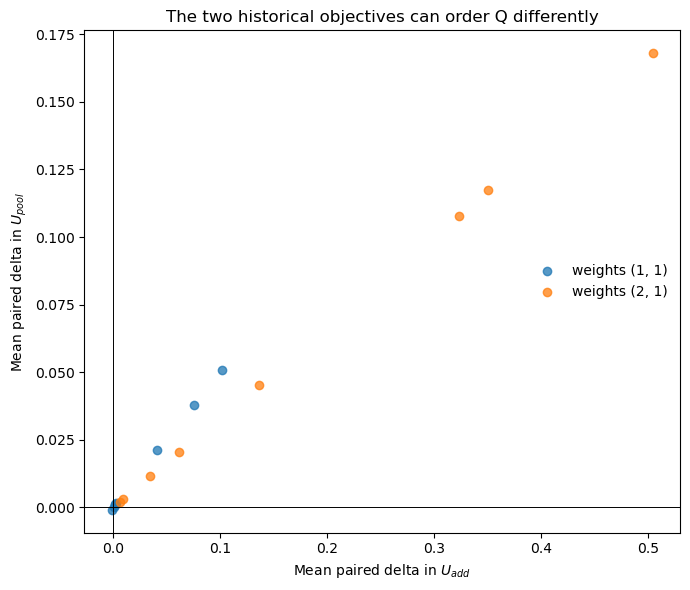

objective,threshold_pair,balk_high,weight_label,Q_left,Q_right,orders_differ
1,"(5, 12)",0.5,"(1, 1)",8,16,False
2,"(5, 12)",0.5,"(1, 1)",8,24,False
3,"(5, 12)",0.5,"(1, 1)",8,32,False
5,"(5, 12)",0.5,"(2, 1)",8,16,False
6,"(5, 12)",0.5,"(2, 1)",8,24,False
7,"(5, 12)",0.5,"(2, 1)",8,32,False
10,"(5, 12)",0.5,"(1, 1)",16,24,False
11,"(5, 12)",0.5,"(1, 1)",16,32,False
14,"(5, 12)",0.5,"(2, 1)",16,24,False
15,"(5, 12)",0.5,"(2, 1)",16,32,False


In [12]:
comparison = (
    paired_df.groupby(["threshold_pair", "balk_high", "Q", "weight_label", "objective"])["objective_delta"]
    .mean()
    .unstack("objective")
    .reset_index()
)
fig, ax = plt.subplots(figsize=(7, 6))
for weight_label, group in comparison.groupby("weight_label"):
    ax.scatter(group["U_add"], group["U_pool"], alpha=0.75, label=f"weights {weight_label}")
ax.axhline(0, color="black", linewidth=0.7)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Mean paired delta in $U_{add}$")
ax.set_ylabel("Mean paired delta in $U_{pool}$")
ax.set_title("The two historical objectives can order Q differently")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

order_pairs = comparison.merge(
    comparison,
    on=["threshold_pair", "balk_high", "weight_label"],
    suffixes=("_left", "_right"),
)
order_pairs = order_pairs[order_pairs["Q_left"] < order_pairs["Q_right"]].copy()
order_pairs["add_order"] = np.sign(order_pairs["U_add_left"] - order_pairs["U_add_right"])
order_pairs["pool_order"] = np.sign(order_pairs["U_pool_left"] - order_pairs["U_pool_right"])
order_pairs["orders_differ"] = order_pairs["add_order"] != order_pairs["pool_order"]
display(order_pairs[["threshold_pair", "balk_high", "weight_label", "Q_left", "Q_right", "orders_differ"]].head(20))

## Optional Widgets

In [13]:
if HAS_WIDGETS:
    threshold_widget = widgets.Dropdown(options=scenario_df["threshold_pair"].drop_duplicates().tolist(), description="Thresholds")
    balk_widget = widgets.Dropdown(options=sorted(scenario_df["balk_high"].unique()), description="Balk high")
    widgets.interact(plot_class_context, threshold_pair=threshold_widget, balk_high=balk_widget)
else:
    print("ipywidgets is not installed. Use PLOT_THRESHOLD_PAIR and PLOT_BALK_HIGH in the plain plot cell.")

interactive(children=(Dropdown(description='Thresholds', options=('(9, 9)', '(5, 12)'), value='(9, 9)'), Dropd…

## Final Explicit Answers

These answers describe the simulated historical grid. They are not a recommendation for any value of $Q$.

In [14]:
class_delta = paired_class_df.groupby("class_id")[["delta_served_rate", "delta_no_offer_rate", "delta_mean_offered_booking_delay"]].mean()

baseline_run = run_df.loc[run_df["Q"] == 0, ["scenario_id", "seed", "served_rate"]].rename(columns={"served_rate": "q0_served_rate"})
paired_run = run_df.loc[run_df["Q"] > 0].merge(baseline_run, on=["scenario_id", "seed"], validate="many_to_one")
paired_run["delta_served_rate"] = paired_run["served_rate"] - paired_run["q0_served_rate"]

order_context = order_pairs.groupby(["threshold_pair", "balk_high", "weight_label"])["orders_differ"].any()
order_context_count = int(order_context.sum())
order_context_total = int(order_context.size)

wait_access_context = (
    paired_class_df.groupby(["threshold_pair", "balk_high", "Q", "class_id"])[["delta_no_offer_rate", "delta_mean_offered_booking_delay"]]
    .mean()
    .reset_index()
)
fewer_offers_lower_wait = (wait_access_context["delta_no_offer_rate"] > 0) & (wait_access_context["delta_mean_offered_booking_delay"] < 0)
undefined_wait_contexts = int(wait_access_context["delta_mean_offered_booking_delay"].isna().sum())

sign_stability = (
    paired_df.assign(positive=lambda x: x["objective_delta"] > 0)
    .groupby(["scenario_id", "Q", "weight_label", "objective"])["positive"]
    .mean()
)
stable_share = float(((sign_stability <= 0.2) | (sign_stability >= 0.8)).mean())

max_run_error = checks_df.loc[checks_df["check"] == "run outcome partition", "max_absolute_error"].iloc[0]
max_class_error = checks_df.loc[checks_df["check"] == "class outcome partition", "max_absolute_error"].iloc[0]
max_unresolved = int(run_df["total_unresolved_booked"].max())

answers = [
    f"Redistribution: relative to paired Q=0, the mean Class 1 served-rate change is {class_delta.loc[1, 'delta_served_rate']:+.3f} and the mean Class 2 change is {class_delta.loc[2, 'delta_served_rate']:+.3f}. Strict reservation redistributes access toward Class 1 when those signs are positive and negative, respectively.",
    f"Overall service versus priority: the mean overall served-rate change is {paired_run['delta_served_rate'].mean():+.3f}. This should be read beside the Class 1 change of {class_delta.loc[1, 'delta_served_rate']:+.3f}; a priority gain can coexist with an overall service loss.",
    f"Low waits due to fewer offers: lower mean wait and a higher no-offer rate occur together in {int(fewer_offers_lower_wait.sum())} of {len(wait_access_context)} grouped class-Q contexts. There are {undefined_wait_contexts} contexts with undefined wait because offers fall to zero. A low observed wait is conditional on receiving an offer and does not by itself show broad access.",
    f"Objectives rank differently: {'yes' if order_context_count else 'no in this run'}. At least one pairwise Q ordering differs in {order_context_count} of {order_context_total} scenario-weight contexts. No preferred Q is selected.",
    f"Seed stability: {stable_share:.1%} of scenario-Q-weight-objective cells have at least 80% of seeds on the same side of zero. The seed plot and confidence intervals show where conclusions are less stable.",
    f"Unresolved and accounting: the largest unresolved booked count is {max_unresolved}. Maximum run and class partition errors are {max_run_error:g} and {max_class_error:g}; all accounting assertions pass.",
]

for answer in answers:
    print("- " + answer)

- Redistribution: relative to paired Q=0, the mean Class 1 served-rate change is +0.150 and the mean Class 2 change is -0.122. Strict reservation redistributes access toward Class 1 when those signs are positive and negative, respectively.
- Overall service versus priority: the mean overall served-rate change is +0.014. This should be read beside the Class 1 change of +0.150; a priority gain can coexist with an overall service loss.
- Low waits due to fewer offers: lower mean wait and a higher no-offer rate occur together in 0 of 16 grouped class-Q contexts. There are 2 contexts with undefined wait because offers fall to zero. A low observed wait is conditional on receiving an offer and does not by itself show broad access.
- Objectives rank differently: no in this run. At least one pairwise Q ordering differs in 0 of 4 scenario-weight contexts. No preferred Q is selected.
- Seed stability: 65.6% of scenario-Q-weight-objective cells have at least 80% of seeds on the same side of zero. 